## DFT vs. MLIPs Energy Comparison Pipeline

In [37]:
from pathlib import Path
import numpy as np
from ase.io import iread, read, write

#### 0. Configuration

In [38]:
def make_run(label, bext, ads=None, slab=None, gas=None):
    def path(snippet, default):
        if snippet and '/' in snippet:
            return snippet  # fully specified path, use as-is
        name = snippet or label + default
        return f"dft-data/{name}_BEXT{bext}/vasprun.xml"
    return {
        "label": label,
        "bext":  bext,
        "ads":   path(ads,  "diss2"),
        "slab":  path(slab, "surf"),
        "gas":   path(gas,  "mag2"),
    }

In [39]:
# USER INPUT HERE

RUNS = ([make_run("NH3", b) for b in [0.1, 0.24, 0.37, 0.5]] +
        [make_run("H2", b, slab="NH3surf", gas="dft-data/H2_gas/vasprun.xml") for b in [0.1, 0.24, 0.37, 0.5]]
)

MODELS = [
        ("MACE",       "/Users/zschwab/miniconda3/envs/mlip-mace/bin/python",       "model-scripts/run_mace.py"),
        ("MatterSim",  "/Users/zschwab/miniconda3/envs/mlip-mattersim/bin/python",  "model-scripts/run_mattersim.py"),
        ("UMA",        "/Users/zschwab/miniconda3/envs/mlip-uma/bin/python",        "model-scripts/run_uma.py"),
]

#### 1. DFT data ingestion

In [40]:
# load vasp trajectories into ASE Atoms obj.
# metadata: (system type, source dataset, external b-field strength)

def load_frames(path):
    frames = []
    for f in iread(path):
        frames.append(f)
    
    return frames

def load_frame(path):
    frame = read(path)
    
    return frame

In [41]:
for run in RUNS:
    run_id = f"{run['label']}_BEXT{run['bext']}"
    
    run["xyz_ads"]  = f"model-scripts/script-data/input_ads_{run_id}.xyz"
    run["xyz_slab"] = f"model-scripts/script-data/input_slab_{run_id}.xyz"
    run["xyz_gas"]  = f"model-scripts/script-data/input_gas_{run_id}.xyz"

    write(run["xyz_ads"],  load_frames(run["ads"]))
    write(run["xyz_slab"], load_frame (run["slab"]))
    write(run["xyz_gas"],  load_frame (run["gas"]))

#### 2. run MLIPs (MACE, MatterSim, UMA)

In [43]:
import subprocess
import os
env = os.environ.copy()
env["MPLBACKEND"] = "Agg"

for run in RUNS:
    run_id = f"{run['label']}_BEXT{run['bext']}"
    run["results"] = {}
    for name, python, script in MODELS:
        out = f"model-scripts/script-data/results_{name}_{run_id}.npz"
        r = subprocess.run(
            [python, script, run["xyz_ads"], run["xyz_slab"], run["xyz_gas"], out],
            capture_output=True, text=True, env=env
        )
        run["results"][name] = out
        if (r.returncode != 0):
            print(f"-- [{run_id}] ({name}): failed")
            if r.stdout: print(r.stdout)
            if r.stderr: print(r.stderr)
            print("Return code:", r.returncode)
        print(f"-- [{run_id}] ({name}): success")

-- [NH3_BEXT0.1] (MACE): success
-- [NH3_BEXT0.1] (MatterSim): success
-- [NH3_BEXT0.1] (UMA): success
-- [NH3_BEXT0.24] (MACE): success
-- [NH3_BEXT0.24] (MatterSim): success
-- [NH3_BEXT0.24] (UMA): success
-- [NH3_BEXT0.37] (MACE): success
-- [NH3_BEXT0.37] (MatterSim): success
-- [NH3_BEXT0.37] (UMA): success
-- [NH3_BEXT0.5] (MACE): success
-- [NH3_BEXT0.5] (MatterSim): success
-- [NH3_BEXT0.5] (UMA): success
-- [H2_BEXT0.1] (MACE): success
-- [H2_BEXT0.1] (MatterSim): success
-- [H2_BEXT0.1] (UMA): success
-- [H2_BEXT0.24] (MACE): success
-- [H2_BEXT0.24] (MatterSim): success
-- [H2_BEXT0.24] (UMA): success
-- [H2_BEXT0.37] (MACE): success
-- [H2_BEXT0.37] (MatterSim): success
-- [H2_BEXT0.37] (UMA): success
-- [H2_BEXT0.5] (MACE): success
-- [H2_BEXT0.5] (MatterSim): success
-- [H2_BEXT0.5] (UMA): success


#### 3. plot results (model E<sub>slab+ads</sub> vs. DFT E<sub>slab+ads</sub>)

In [70]:
import math
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

ncols = min(len(RUNS), 3)
nrows = math.ceil(len(RUNS) / 3)
col_w = 5

In [48]:
for run in RUNS:
    frames = read(run["xyz_ads"], index=":")
    run["dft"] = {
        "energies":    np.array([a.get_potential_energy() for a in frames]),
        "slab_energy": read(run["xyz_slab"]).get_potential_energy(),
        "gas_energy":  read(run["xyz_gas"]).get_potential_energy(),
    }

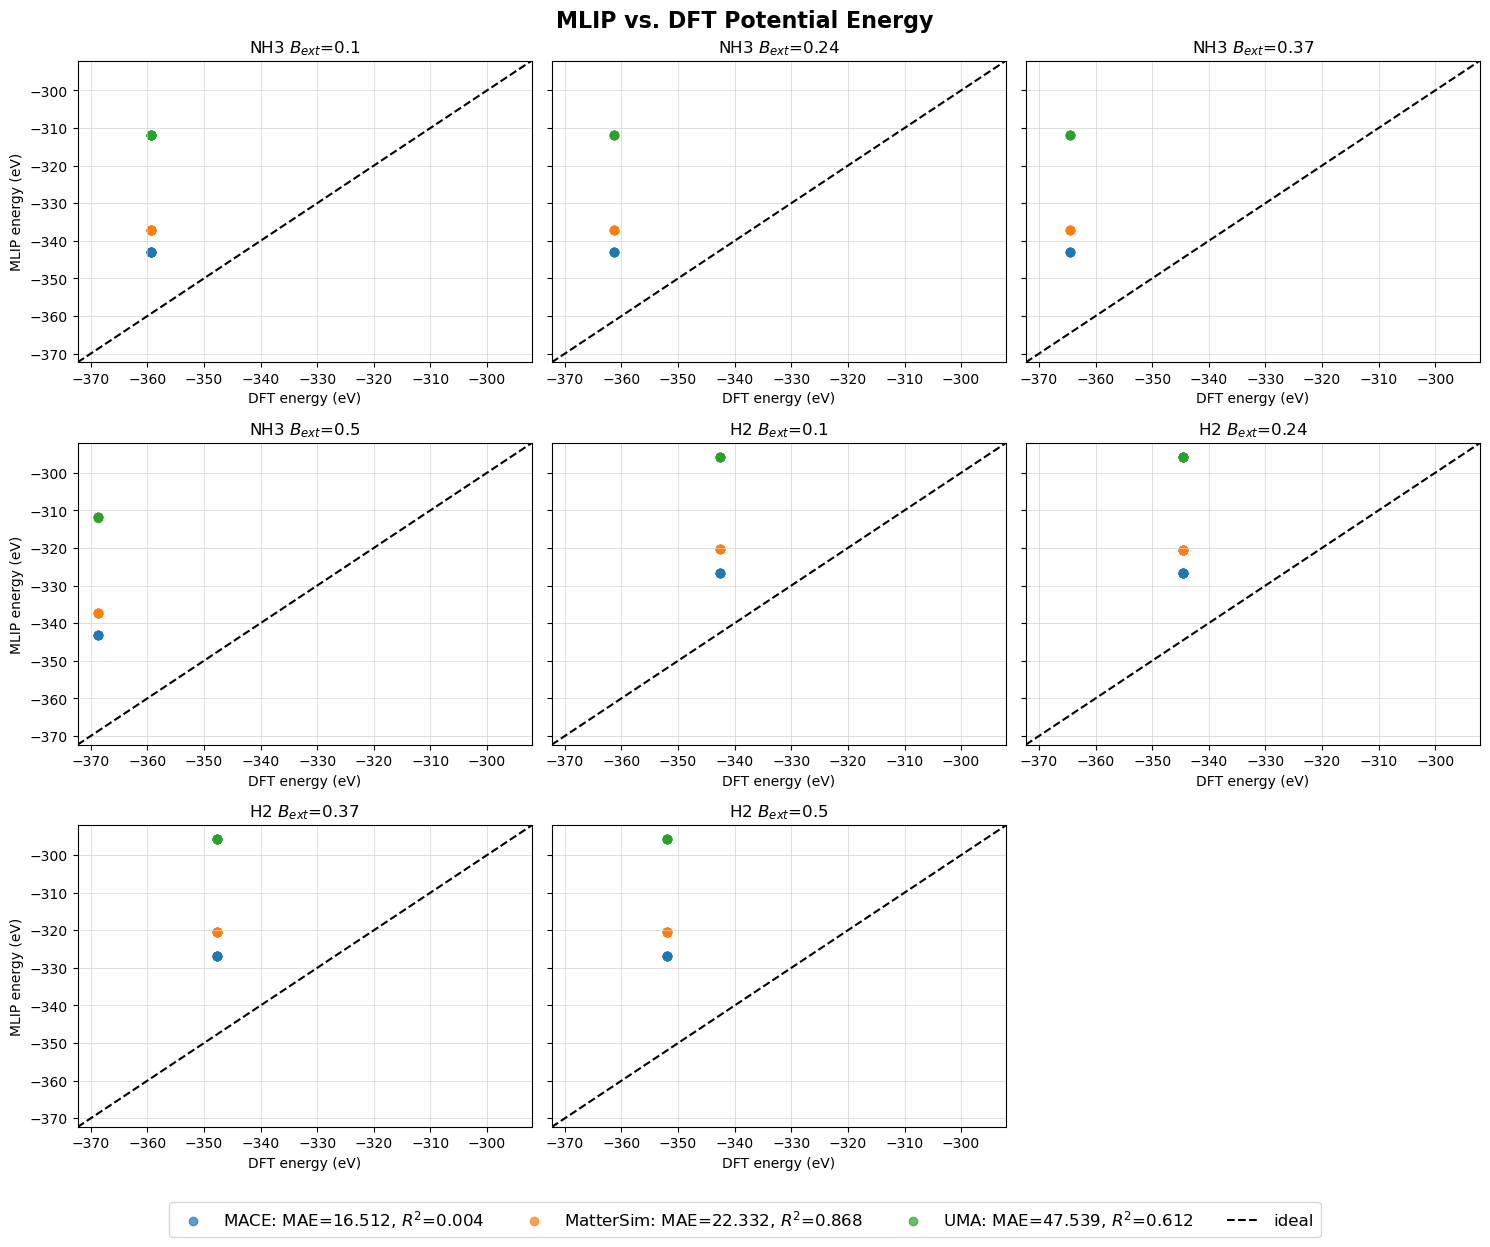

In [80]:
# --- Figure 1: Parity ---
fig1, axes1 = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4))
axes1 = np.array(axes1).flatten()
fig1.suptitle("MLIP vs. DFT Potential Energy", fontsize=16, fontweight='semibold')

# compute global limits
all_e = [e for run in RUNS
            for name, *_ in MODELS
            for e in [run["dft"]["energies"],
                    np.load(run["results"][name])["mlip_energies"]]]
global_min = min(e.min() for e in all_e)
global_max = max(e.max() for e in all_e)
padding = (global_max - global_min) * 0.05
global_min -= padding
global_max += padding

for i, run in enumerate(RUNS):
    ax = axes1[i]
    dft_e = run["dft"]["energies"]
    for j, (name, *_) in enumerate(MODELS):
        color = plt.cm.tab10(j)
        mlip_e = np.load(run["results"][name])["mlip_energies"]
        mae = np.mean(np.abs(mlip_e - dft_e))
        mae = np.mean(np.abs(mlip_e - dft_e))
        r2 = pearsonr(dft_e, mlip_e).statistic ** 2
        ax.scatter(dft_e, mlip_e, alpha=0.7, color=color, label=f"{name}: MAE={mae:.3f}, $R^2$={r2:.3f}")        # ax.scatter(dft_e, mlip_e, alpha=0.7, color=color, label=f"{name} MAE={mae:.3f}")
    ax.plot([global_min, global_max], [global_min, global_max], 'k--', label="ideal")
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(global_min, global_max)
    ax.grid(color='lightgrey', linewidth=0.5)
    ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
    ax.set_xlabel("DFT energy (eV)")
    if i % ncols == 0:
        ax.set_ylabel("MLIP energy (eV)")
    else:
        ax.set_yticklabels([])

for ax in axes1[len(RUNS):]:
    ax.set_visible(False)

handles, labels = axes1[0].get_legend_handles_labels()
fig1.legend(handles, labels, loc='lower center', ncol=len(MODELS)+1, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()

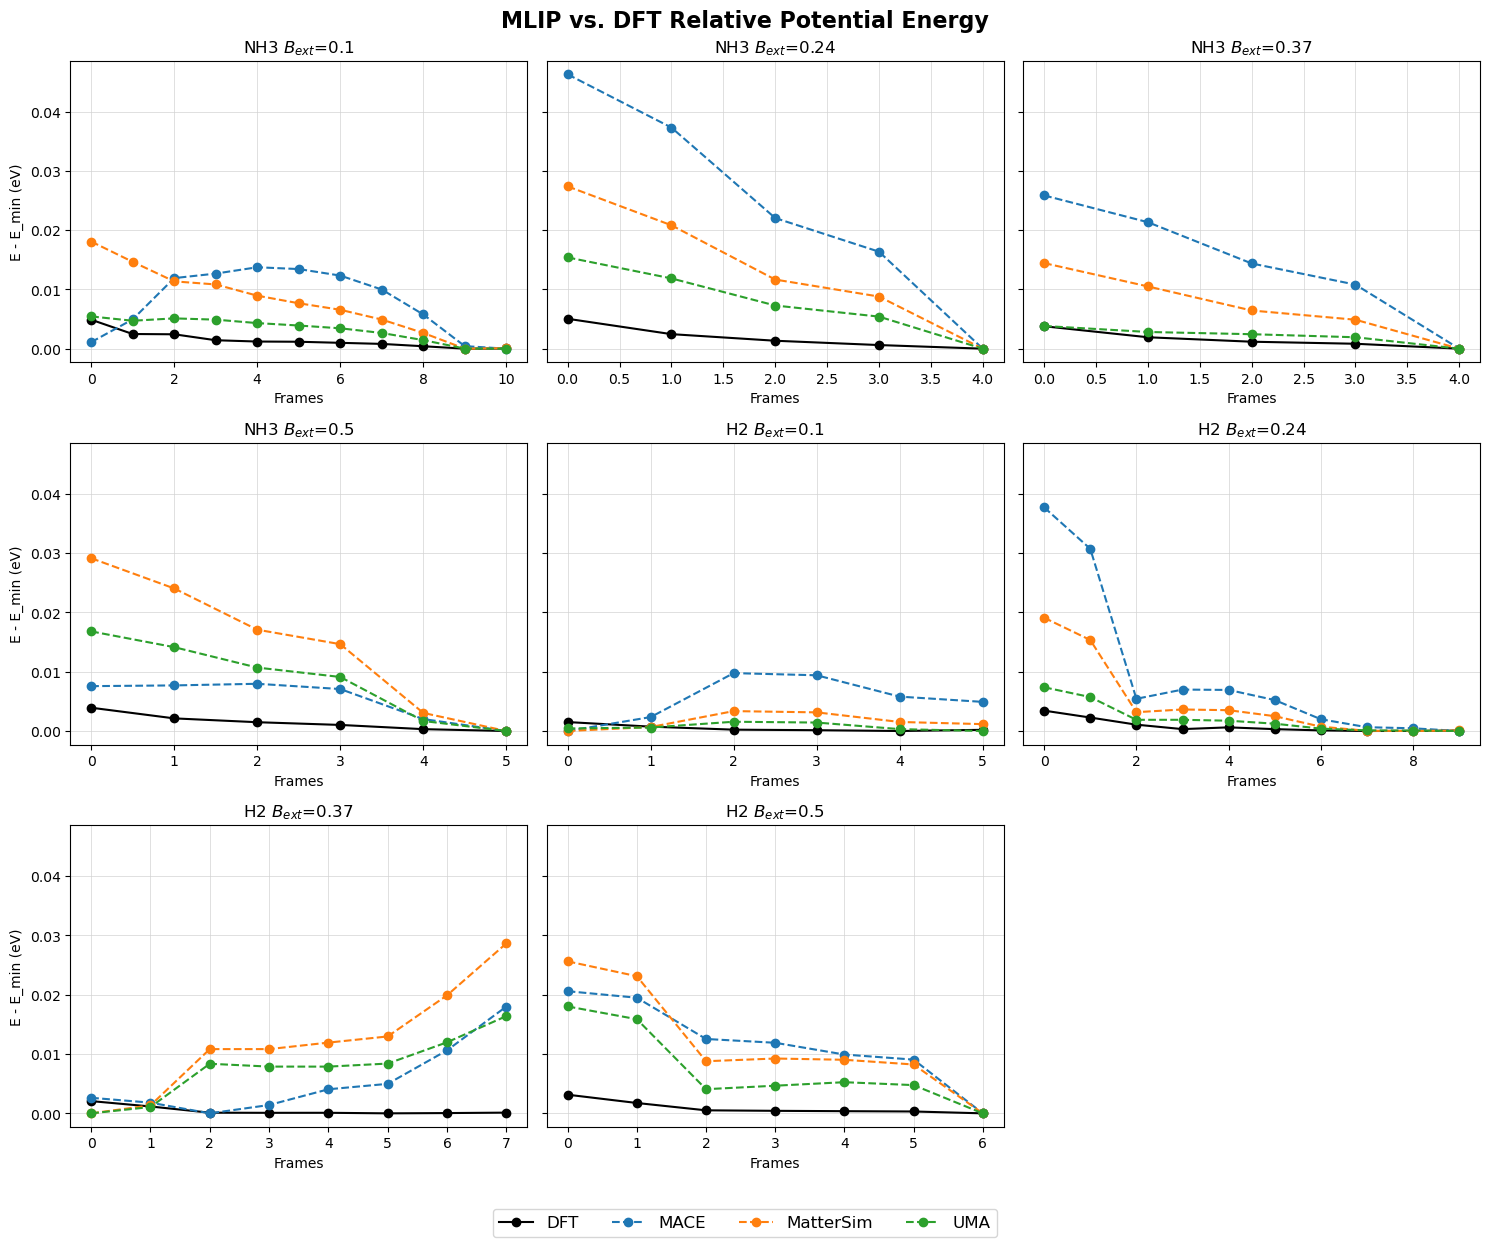

In [81]:
# --- Figure 2: Relative Energy ---
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4))
axes2 = np.array(axes2).flatten()
fig2.suptitle("MLIP vs. DFT Relative Potential Energy", fontsize=16, fontweight='semibold')

# compute global y limits
all_rel = []
for run in RUNS:
    dft_e = run["dft"]["energies"]
    all_rel.append(dft_e - dft_e.min())
    for name, *_ in MODELS:
        mlip_e = np.load(run["results"][name])["mlip_energies"]
        all_rel.append(mlip_e - mlip_e.min())
rel_min = min(e.min() for e in all_rel)
rel_max = max(e.max() for e in all_rel)
padding = (rel_max - rel_min) * 0.05
rel_min -= padding
rel_max += padding

for i, run in enumerate(RUNS):
    ax = axes2[i]
    dft_e = run["dft"]["energies"]
    dft_rel = dft_e - dft_e.min()
    frames = range(len(dft_e))
    ax.plot(frames, dft_rel, 'k-o', label="DFT")
    for j, (name, *_) in enumerate(MODELS):
        color = plt.cm.tab10(j)
        mlip_e = np.load(run["results"][name])["mlip_energies"]
        mlip_rel = mlip_e - mlip_e.min()
        ax.plot(frames, mlip_rel, '--o', color=color, label=name)
    ax.set_ylim(rel_min, rel_max)
    ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
    ax.set_xlabel("Frames")
    ax.grid(color='lightgrey', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel("E - E_min (eV)")
    else:
        ax.set_yticklabels([])

for ax in axes2[len(RUNS):]:
    ax.set_visible(False)

handles, labels = axes2[0].get_legend_handles_labels()
fig2.legend(handles, labels, loc='lower center', ncol=len(MODELS)+1, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()

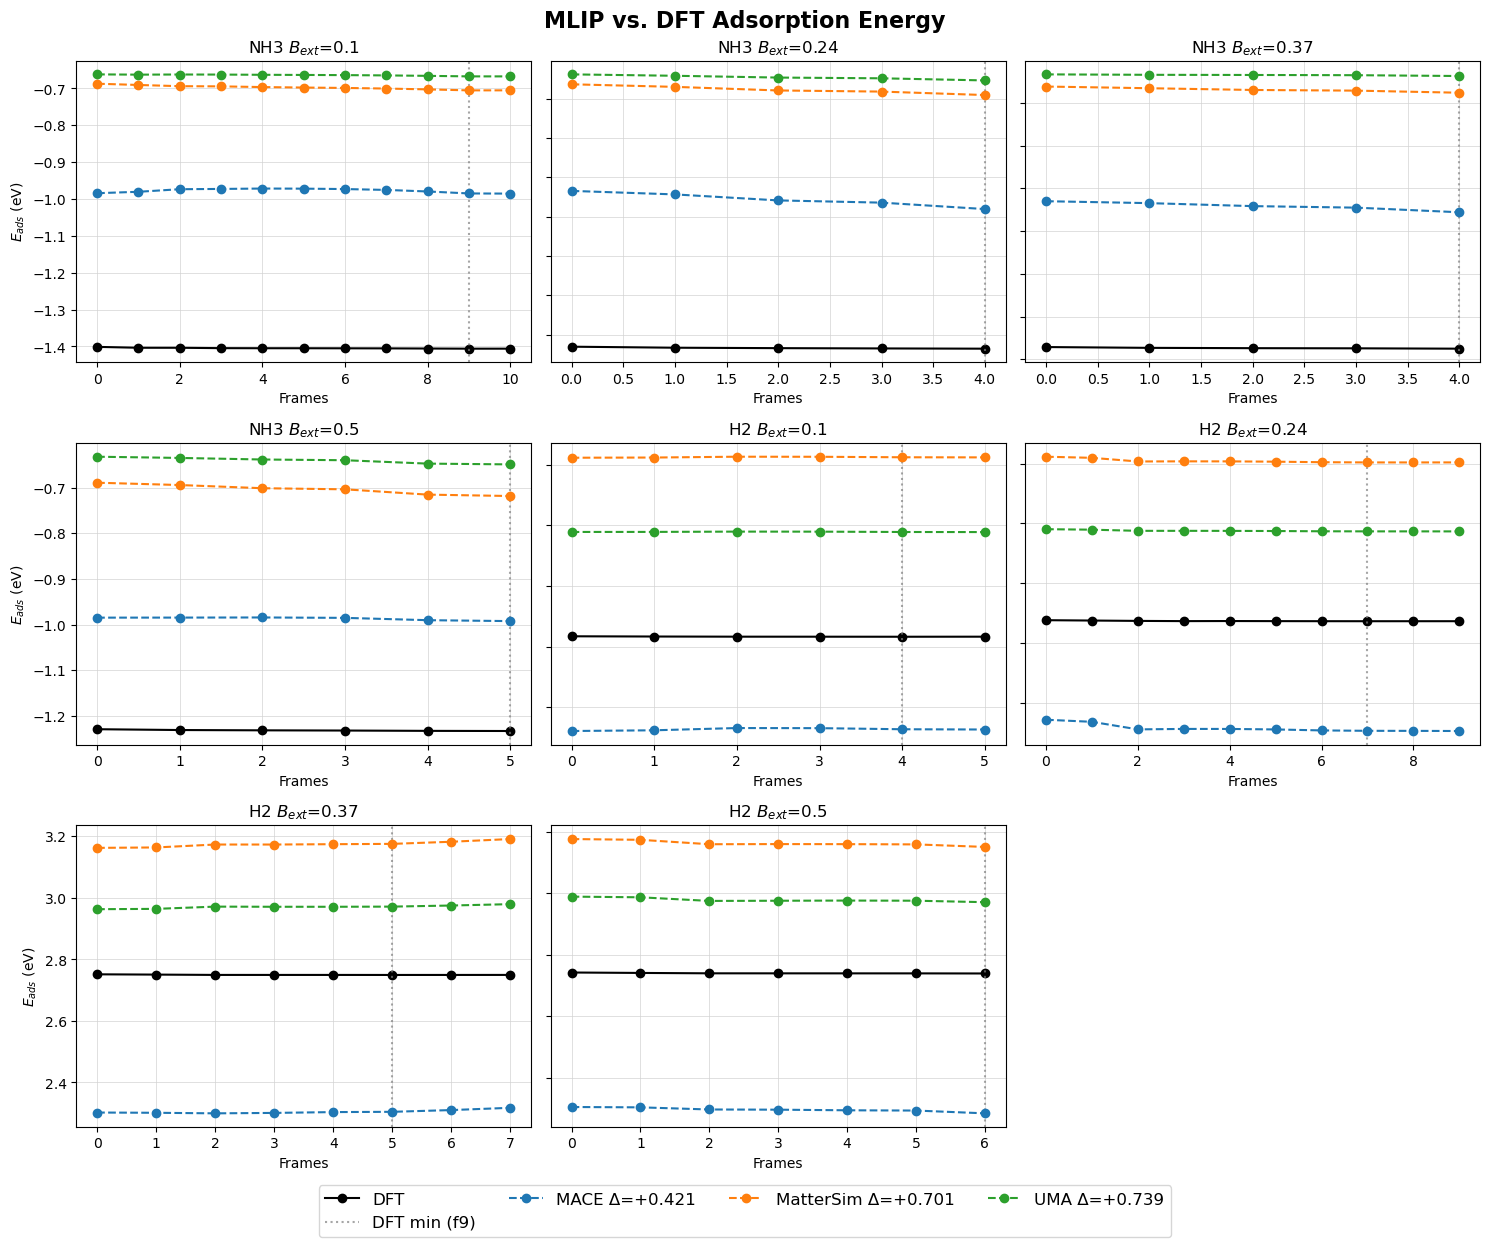

In [82]:
# --- Figure 3: Adsorption Energy ---
fig3, axes3 = plt.subplots(nrows, ncols, figsize=(ncols*col_w, nrows*4))
axes3 = np.array(axes3).flatten()
fig3.suptitle("MLIP vs. DFT Adsorption Energy", fontsize=16, fontweight='semibold')

for i, run in enumerate(RUNS):
    ax = axes3[i]
    dft_e   = run["dft"]["energies"]
    dft_ads = dft_e - run["dft"]["slab_energy"] - run["dft"]["gas_energy"]
    dft_min = np.argmin(dft_ads)
    frames  = range(len(dft_e))
    ax.plot(frames, dft_ads, 'k-o', label="DFT")
    ax.axvline(dft_min, color='gray', linestyle=':', alpha=0.7, label=f"DFT min (f{dft_min})")
    for j, (name, *_) in enumerate(MODELS):
        color = plt.cm.tab10(j)
        res = np.load(run["results"][name])
        mlip_ads = res["mlip_energies"] - res["slab_energy"] - res["gas_energy"]
        err = mlip_ads[dft_min] - dft_ads[dft_min]
        ax.plot(frames, mlip_ads, '--o', color=color, label=f"{name} Δ={err:+.3f}")
    ax.set_title(f"{run['label']} $B_{{ext}}$={run['bext']}")
    ax.set_xlabel("Frames")
    ax.grid(color='lightgrey', linewidth=0.5)
    if i % ncols == 0:
        ax.set_ylabel("$E_{ads}$ (eV)")
    else:
        ax.set_yticklabels([])

for ax in axes3[len(RUNS):]:
    ax.set_visible(False)

handles, labels = axes3[0].get_legend_handles_labels()
fig3.legend(handles, labels, loc='lower center', ncol=len(MODELS)+1, bbox_to_anchor=(0.5, -0.05), fontsize=12)

plt.tight_layout()
plt.show()